consommation de carburant (LSTM, TinyML)
**Projet de fin de module — Deep Learning**

Objectif : prédire la **consommation de carburant** (`FUEL CONSUMPTION`, en L/100 km)
d'un véhicule à partir de ses attributs, avec un petit **réseau LSTM** entraîné en
régression. Le notebook reprend le TP de référence du professeur (cadre *TinyML*) :
le modèle, très léger, est destiné à être déployé sur microcontrôleur.

> Ce TP utilise **TensorFlow/Keras** (et non PyTorch comme les TP1/TP2) afin de
> rester fidèle au notebook du professeur et de permettre l'export TinyML.
> Dataset : *Vehicle Attributes and Emissions* (Kaggle `krupadharamshi/fuelconsumption`).

## 0. Imports et chargement des données

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")
os.makedirs("figs", exist_ok=True)
tf.random.set_seed(42); np.random.seed(42)

In [2]:
# Recherche du fichier ; sinon telechargement Kaggle ; sinon upload manuel.
CSV = "FuelConsumption.csv"
def find_csv():
    for p in [CSV, "data/" + CSV, "/content/" + CSV, "/content/data/" + CSV]:
        if os.path.exists(p):
            return p
    return None

path = find_csv()
if path is None:
    try:
        import kagglehub
        d = kagglehub.dataset_download("krupadharamshi/fuelconsumption")
        for root, _, files in os.walk(d):
            for f in files:
                if f.lower().endswith(".csv"):
                    path = os.path.join(root, f)
    except Exception as e:
        print("kagglehub indisponible :", e)
if path is None:
    raise FileNotFoundError(
        "Deposez FuelConsumption.csv dans le repertoire de travail "
        "(Kaggle : krupadharamshi/fuelconsumption).")

df = pd.read_csv(path)
df.columns = df.columns.str.strip()   # corrige les noms ('COEMISSIONS ' -> 'COEMISSIONS')
print("Fichier :", path)
print("Dimensions :", df.shape)
df.head()

100%|██████████| 6.25k/6.25k [00:00<00:00, 3.84MB/s]

Extracting files...
Fichier : /root/.cache/kagglehub/datasets/krupadharamshi/fuelconsumption/versions/1/FuelConsumption (1).csv
Dimensions : (639, 10)


,Year,MAKE,MODEL,VEHICLE CLASS,ENGINE SIZE,CYLINDERS,TRANSMISSION,FUEL,FUEL CONSUMPTION,COEMISSIONS
0,2000,ACURA,1.6EL,COMPACT,1.6,4,A4,X,10.5,216
1,2000,ACURA,1.6EL,COMPACT,1.6,4,M5,X,9.8,205
2,2000,ACURA,3.2TL,MID-SIZE,3.2,6,AS5,Z,13.7,265
3,2000,ACURA,3.5RL,MID-SIZE,3.5,6,A4,Z,15.0,301
4,2000,ACURA,INTEGRA,SUBCOMPACT,1.8,4,A4,X,11.4,230


## 1. Nettoyage des données
Suppression des valeurs manquantes et des doublons.

In [3]:
df = df.dropna().drop_duplicates().reset_index(drop=True)
print(f"Apres nettoyage : {df.shape[0]} lignes, {df.shape[1]} colonnes")
df.describe()

Apres nettoyage : 638 lignes, 10 colonnes


,Year,ENGINE SIZE,CYLINDERS,FUEL CONSUMPTION,COEMISSIONS
count,638.0,638.000000,638.000000,638.000000,638.000000
mean,2000.0,3.264577,5.802508,14.705956,296.642633
std,0.0,1.231634,1.624535,3.303962,65.420203
min,2000.0,1.000000,3.000000,4.900000,104.000000
25%,2000.0,2.200000,4.000000,12.500000,253.000000
50%,2000.0,3.000000,6.000000,14.400000,288.000000
75%,2000.0,4.300000,6.000000,16.600000,343.000000
max,2000.0,8.000000,12.000000,30.200000,582.000000


## 2. Analyse exploratoire (EDA)
Variables numériques retenues : `ENGINE SIZE`, `CYLINDERS`, `FUEL CONSUMPTION`,
`COEMISSIONS`.

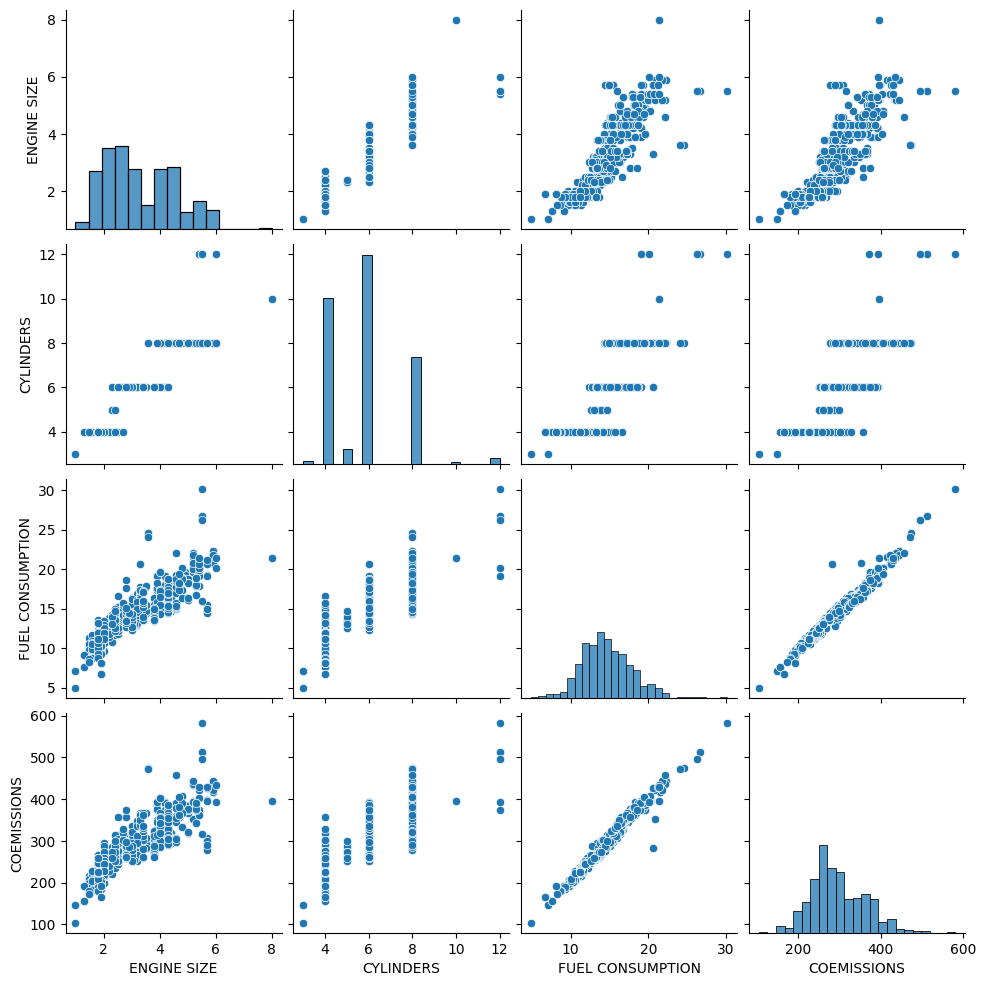

In [4]:
num = ["ENGINE SIZE", "CYLINDERS", "FUEL CONSUMPTION", "COEMISSIONS"]

# Pairplot (figure : figs/tp3_pairplot.png)
sns.pairplot(df[num])
plt.savefig("figs/tp3_pairplot.png", dpi=200, bbox_inches="tight")
plt.show()

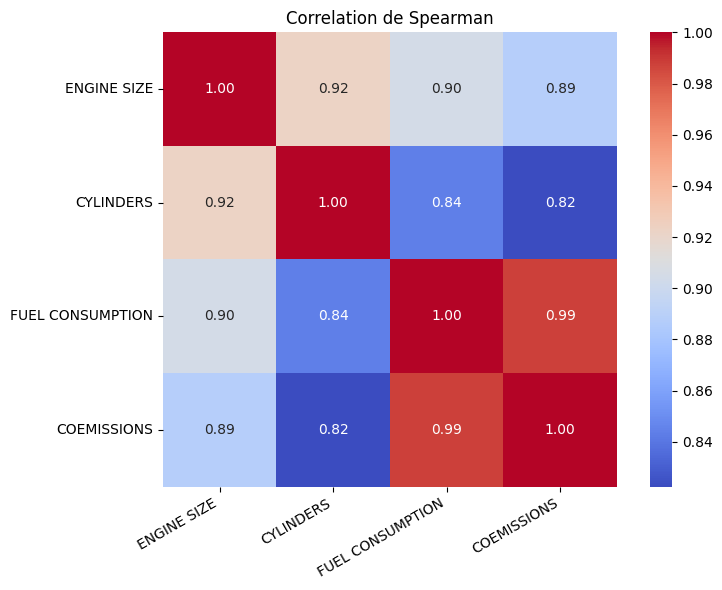

In [5]:
# Matrice de correlation de Spearman (figure : figs/tp3_heatmap.png)
corr = df[num].corr("spearman")
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True,
            xticklabels=num, yticklabels=num)
plt.title("Correlation de Spearman")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("figs/tp3_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. Préparation : variables, normalisation et mise en forme
Conformément au TP du professeur, on prédit `FUEL CONSUMPTION` à partir de
`ENGINE SIZE`, `CYLINDERS` et `COEMISSIONS`. On **standardise les entrées**
(amélioration par rapport au notebook initial, qui les laissait brutes) et on les
met en forme `(échantillons, 3, 1)` attendue par le LSTM.

In [6]:
features = ["ENGINE SIZE", "CYLINDERS", "COEMISSIONS"]
target   = "FUEL CONSUMPTION"

X = df[features].values.astype("float32")
y = df[target].values.astype("float32").reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

# standardisation ajustee sur l'entrainement uniquement
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train).astype("float32")
X_test  = scaler.transform(X_test).astype("float32")

# mise en forme (samples, timesteps=3, features=1)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test  = X_test.reshape(X_test.shape[0],  X_test.shape[1],  1)
print("X_train :", X_train.shape, "| X_test :", X_test.shape)

X_train : (446, 3, 1) | X_test : (192, 3, 1)


## 4. Modèle LSTM de régression
Architecture (identique au TP de référence) : deux couches LSTM (12 unités) puis
deux couches denses. Optimiseur `adamax`, perte `MAE`. Le modèle est minuscule
(~2 300 paramètres), ce qui le rend déployable en TinyML.

In [7]:
def build_lstm(input_shape=(3, 1)):
    model = tf.keras.Sequential([
        layers.Input(shape=input_shape),
        layers.LSTM(12, return_sequences=True),
        layers.LSTM(12),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="linear"),
    ])
    model.compile(optimizer="adamax", loss="mae", metrics=["mae"])
    return model

model = build_lstm((X_train.shape[1], 1))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 3, 12)          │           672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 12)             │         1,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,321 (9.07 KB)

 Trainable params: 2,321 (9.07 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Entraînement

In [8]:
history = model.fit(X_train, y_train, validation_split=0.2,
                    epochs=300, batch_size=32, verbose=0)
print("Entrainement termine.")
print(f"MAE finale  -> train {history.history['mae'][-1]:.3f} | "
      f"val {history.history['val_mae'][-1]:.3f}")

Entrainement termine.
MAE finale  -> train 0.322 | val 0.282


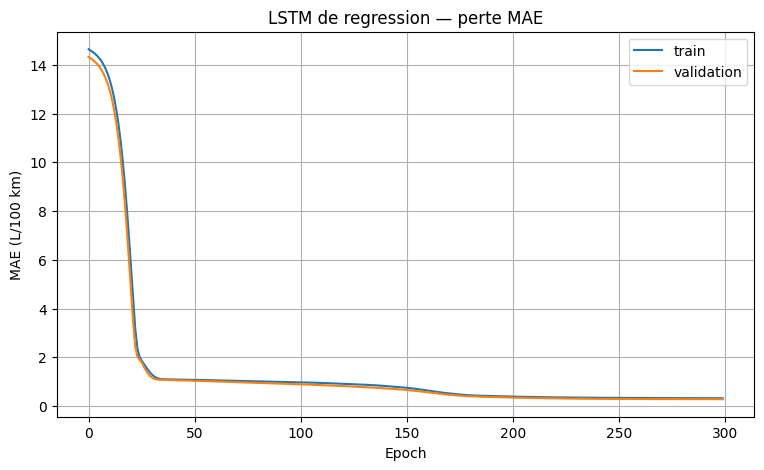

In [9]:
# Courbe de perte (figure : figs/tp3_loss.png)
plt.figure(figsize=(9, 5))
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.title("LSTM de regression — perte MAE")
plt.xlabel("Epoch"); plt.ylabel("MAE (L/100 km)"); plt.legend(); plt.grid(True)
plt.savefig("figs/tp3_loss.png", dpi=200, bbox_inches="tight")
plt.show()

## 6. Évaluation

In [10]:
y_pred = model.predict(X_test, verbose=0)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
print(f"MAE  : {mae:.4f} L/100km")
print(f"RMSE : {rmse:.4f} L/100km")
print(f"R2   : {r2:.4f}")
pd.DataFrame({"MAE": [mae], "RMSE": [rmse], "R2": [r2]}).to_csv(
    "figs/tp3_results.csv", index=False)

MAE  : 0.4122 L/100km
RMSE : 0.8155 L/100km
R2   : 0.9514


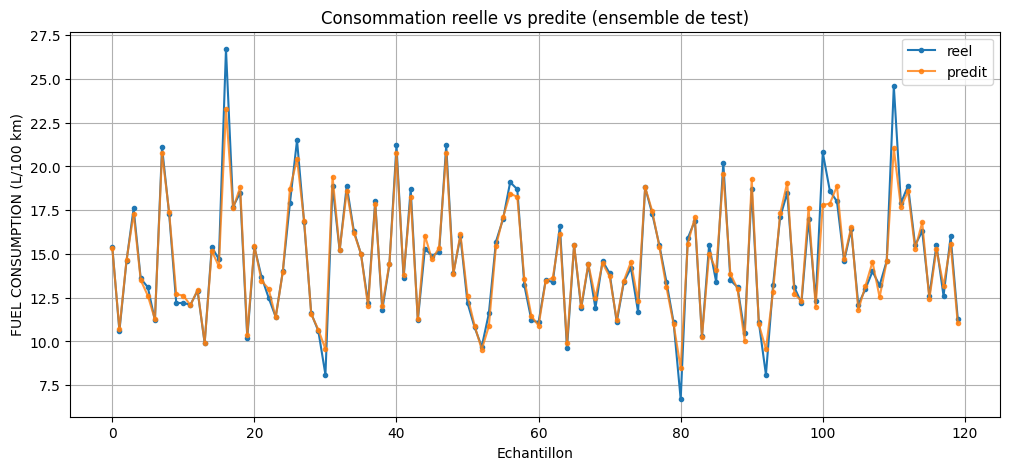

In [11]:
# Valeurs reelles vs predites (figure : figs/tp3_pred.png)
plt.figure(figsize=(12, 5))
plt.plot(y_test[:120], label="reel", marker=".")
plt.plot(y_pred[:120], label="predit", marker=".", alpha=0.8)
plt.title("Consommation reelle vs predite (ensemble de test)")
plt.xlabel("Echantillon"); plt.ylabel("FUEL CONSUMPTION (L/100 km)")
plt.legend(); plt.grid(True)
plt.savefig("figs/tp3_pred.png", dpi=200, bbox_inches="tight")
plt.show()

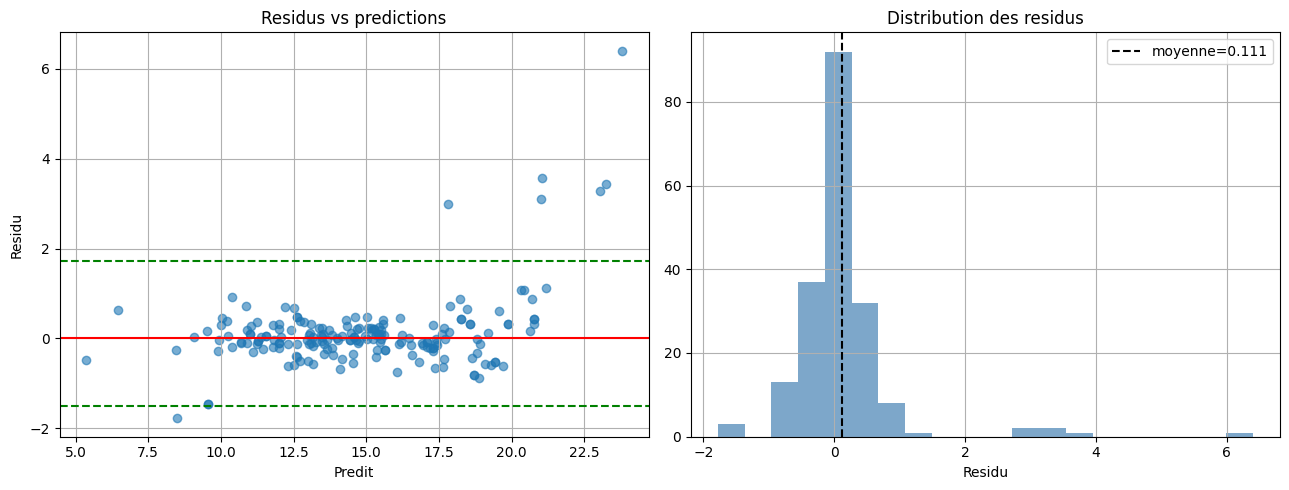

In [12]:
# Analyse des residus (figure : figs/tp3_residuals.png)
residuals = y_test.ravel() - y_pred.ravel()
m, s = residuals.mean(), residuals.std()
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(y_pred.ravel(), residuals, alpha=0.6)
ax[0].axhline(0, color="r"); ax[0].axhline(m + 2*s, color="g", ls="--")
ax[0].axhline(m - 2*s, color="g", ls="--")
ax[0].set_title("Residus vs predictions"); ax[0].set_xlabel("Predit"); ax[0].set_ylabel("Residu")
ax[0].grid(True)
ax[1].hist(residuals, bins=20, color="steelblue", alpha=0.7)
ax[1].axvline(m, color="k", ls="--", label=f"moyenne={m:.3f}")
ax[1].set_title("Distribution des residus"); ax[1].set_xlabel("Residu"); ax[1].legend()
ax[1].grid(True)
plt.tight_layout()
plt.savefig("figs/tp3_residuals.png", dpi=200, bbox_inches="tight")
plt.show()

## 7. Vers le TinyML — export pour microcontrôleur (bonus)
Le modèle ne pèse que ~2 300 paramètres (~9 ko) : il peut être converti en TensorFlow
Lite puis en code C embarquable. La bibliothèque `eloquent_tensorflow` génère
directement ce code. (Étape facultative : ignorer si la bibliothèque n'est pas
disponible.)

In [13]:
try:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "eloquent-tensorflow"])
    from eloquent_tensorflow import convert_model
    c_code = convert_model(model)
    print(c_code[:600])   # apercu de l'en-tete C genere
    with open("model_tinyml.h", "w") as f:
        f.write(c_code)
    print("\nModele C exporte -> model_tinyml.h")
except Exception as e:
    print("Export TinyML ignore :", e)

Export TinyML ignore : 'LSTM' object has no attribute 'input_shape'
